In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
%matplotlib inline
pd.options.display.max_columns = 99

In [4]:
df = pd.read_csv("/content/Popular_Spotify_Songs.csv", encoding='latin1')

In [5]:
df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6
5,Sprinter,"Dave, Central Cee",2,2023,6,1,2186,91,183706234,67,213,88,17,946,141,C#,Major,92,66,58,19,0,8,24
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,34,222,43,13,418,148,F,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,25,89,30,13,194,100,F,Major,67,26,71,37,0,11,4
8,fukumean,Gunna,1,2023,5,15,1096,83,95217315,60,210,48,11,953,130,C#,Minor,85,22,62,12,0,28,9
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,110,66,13,339,170,D,Minor,81,56,48,21,0,8,33


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [7]:
LE = LabelEncoder()
df['track_name'] = LE.fit_transform(df['track_name'])
df['artist(s)_name'] = LE.fit_transform(df['artist(s)_name'])
df['streams'] = LE.fit_transform(df['streams'])
df['key'] = LE.fit_transform(df['key'])
df['mode'] = LE.fit_transform(df['mode'])
df['in_deezer_playlists'] = LE.fit_transform(df['in_deezer_playlists'])
df['in_shazam_charts'] = LE.fit_transform(df['in_shazam_charts'])

In [8]:
df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,687,326,2,2023,7,14,553,147,156,43,263,217,10,185,125,2,0,80,89,83,31,0,8,4
1,397,401,1,2023,3,23,1474,48,125,48,126,262,14,118,92,3,0,71,61,74,7,0,10,4
2,936,431,1,2023,6,30,1397,113,151,94,207,337,14,193,138,7,0,51,32,53,17,0,31,6
3,170,558,1,2019,8,23,7858,100,864,116,207,50,12,149,170,0,0,55,58,72,11,0,11,15
4,864,43,1,2023,5,18,3133,50,499,84,133,330,15,125,144,0,1,65,23,80,14,63,11,6
5,733,123,2,2023,6,1,2186,91,280,67,213,331,17,192,141,3,0,92,66,58,19,0,8,24
6,235,177,2,2023,3,16,3090,50,831,34,222,210,13,123,148,7,1,67,83,76,48,0,8,3
7,156,469,1,2023,7,7,714,43,737,25,89,168,13,59,100,7,0,67,26,71,37,0,11,4
8,919,214,1,2023,5,15,1096,83,933,60,210,228,11,195,130,3,1,85,22,62,12,0,28,9
9,405,452,2,2023,3,17,2953,44,717,49,110,291,13,108,170,4,1,81,56,48,21,0,8,33


In [9]:
SS = StandardScaler()
df['released_year'] = SS.fit_transform(df[['released_year']])
df['in_spotify_playlists'] = SS.fit_transform(df[['in_spotify_playlists']])

In [10]:
df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,687,326,2,0.428590,7,14,-0.588731,147,156,43,263,217,10,185,125,2,0,80,89,83,31,0,8,4
1,397,401,1,0.428590,3,23,-0.472052,48,125,48,126,262,14,118,92,3,0,71,61,74,7,0,10,4
2,936,431,1,0.428590,6,30,-0.481807,113,151,94,207,337,14,193,138,7,0,51,32,53,17,0,31,6
3,170,558,1,0.068567,8,23,0.336718,100,864,116,207,50,12,149,170,0,0,55,58,72,11,0,11,15
4,864,43,1,0.428590,5,18,-0.261878,50,499,84,133,330,15,125,144,0,1,65,23,80,14,63,11,6
5,733,123,2,0.428590,6,1,-0.381851,91,280,67,213,331,17,192,141,3,0,92,66,58,19,0,8,24
6,235,177,2,0.428590,3,16,-0.267326,50,831,34,222,210,13,123,148,7,1,67,83,76,48,0,8,3
7,156,469,1,0.428590,7,7,-0.568334,43,737,25,89,168,13,59,100,7,0,67,26,71,37,0,11,4
8,919,214,1,0.428590,5,15,-0.519940,83,933,60,210,228,11,195,130,3,1,85,22,62,12,0,28,9
9,405,452,2,0.428590,3,17,-0.284682,44,717,49,110,291,13,108,170,4,1,81,56,48,21,0,8,33


In [11]:
df.shape

(953, 24)

In [12]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [13]:
X_question = df.iloc[:,:]
q_mean = X_question.mean(axis=0)
total_mean = q_mean.mean()

In [14]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level=0,inplace=True)

<Axes: xlabel='index', ylabel='mean'>

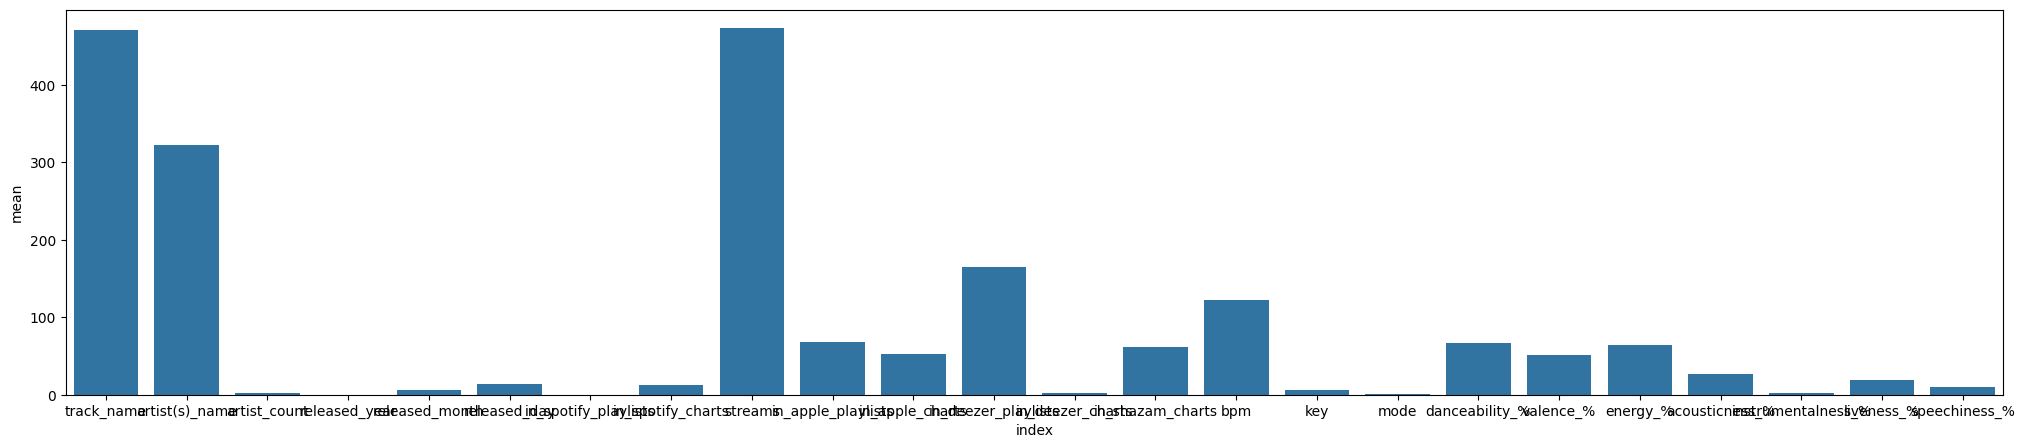

In [15]:
plt.figure(figsize=(25,5))
sns.barplot(x='index',y='mean',data=q_mean)

<Axes: >

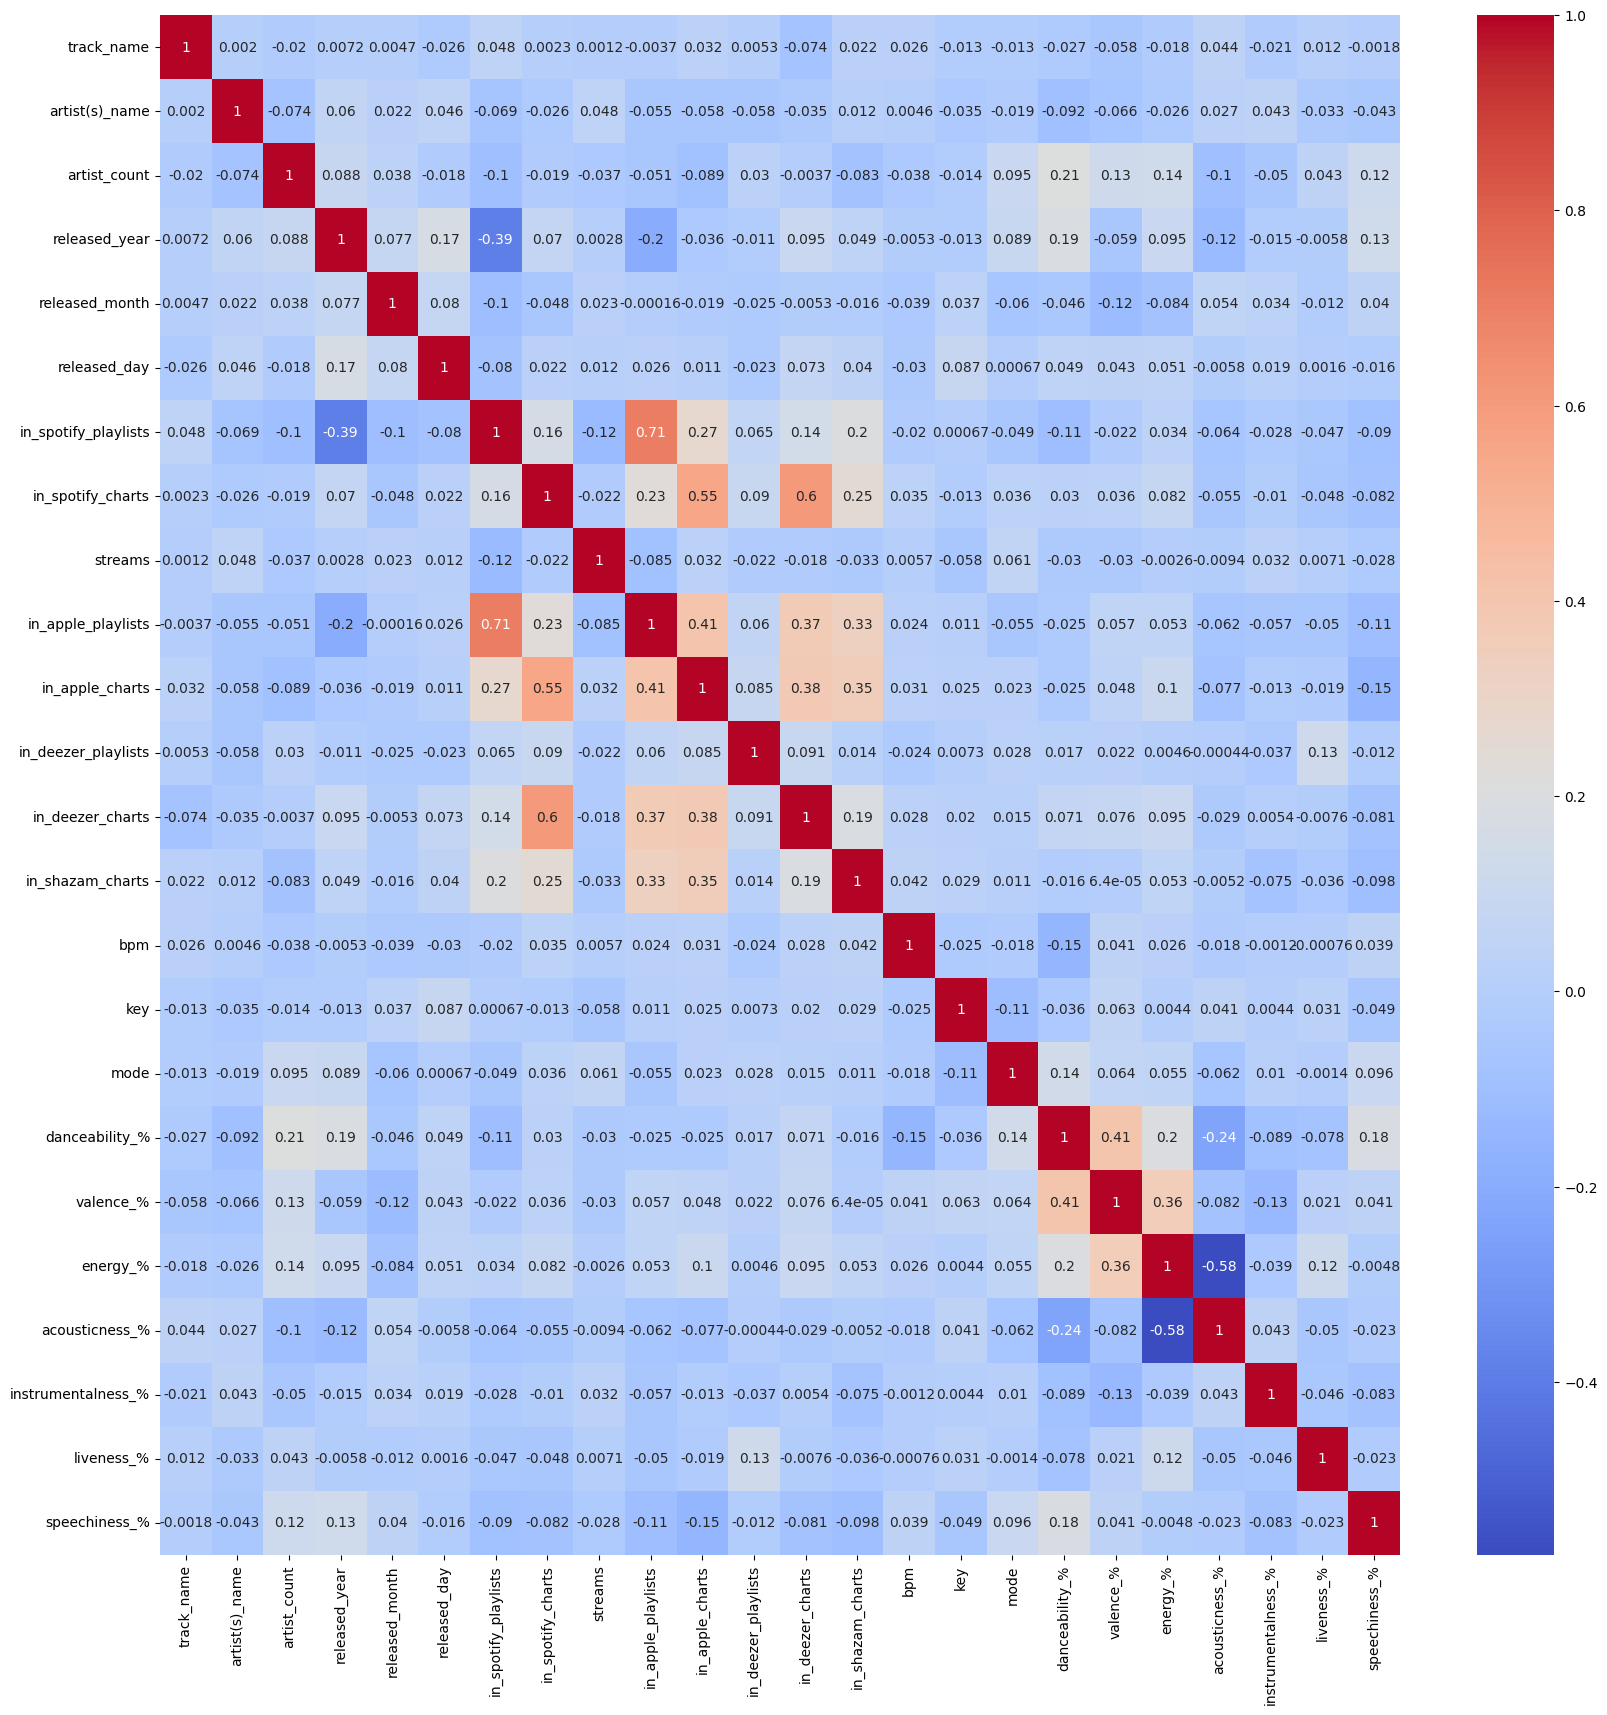

In [16]:
corr = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True,cmap='coolwarm')


In [17]:
X = df.iloc[:,:]
pca = PCA(n_components=2,random_state=42)
pca.fit_transform(X)

array([[-302.21562276,  238.7632952 ],
       [-347.70874604,  -49.89958993],
       [-287.18196961,  487.80771813],
       ...,
       [ 321.807984  , -479.61757996],
       [-366.60541453, -211.29471915],
       [ 419.43240622, -456.09923205]])

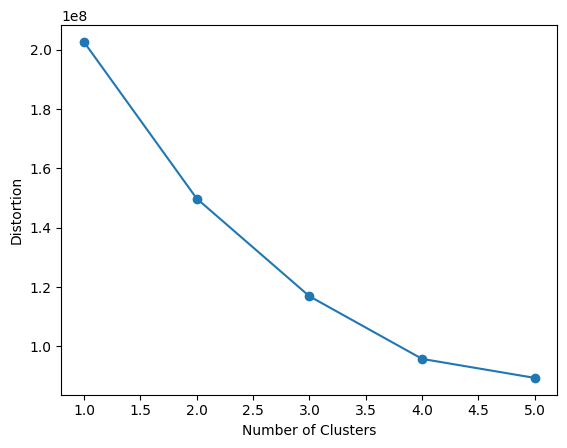

In [18]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42)
  km.fit(X)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

In [20]:
model = KMeans(n_clusters=4,init='k-means++',random_state=42,n_init=10)
X_pca = pca.transform(X)
model.fit(X_pca)
y = model.predict(X_pca)

In [21]:
model

KMeans(n_clusters=4, n_init=10, random_state=42)

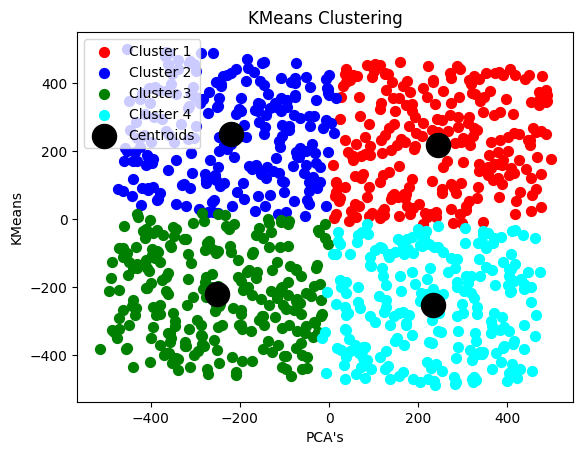

In [22]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='blue',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green',label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=50,c='cyan',label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=300,c='black',label='Centroids')
plt.xlabel("PCA's")
plt.ylabel("KMeans")
plt.title("KMeans Clustering")
plt.legend()
plt.show()